<a href="https://colab.research.google.com/github/mehtab-ratnani/Health-Risk-Classification/blob/main/Health_Risk_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OPEN ENDED LAB 07

---


Name : Mehtab



Roll No: 24F-AI-118

Section : C

Project : Heallth Risk Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [4]:
# LoadDataset
df_raw = pd.read_csv("diabetes.csv")

print(f"Shape: {df_raw.shape}")
print("\n1st 5 rows:")
df_raw.head()

Shape: (768, 9)

1st 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


/tmp/ipykernel_2012/388955972.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x="Outcome", ax=axes[0], palette="pastel")


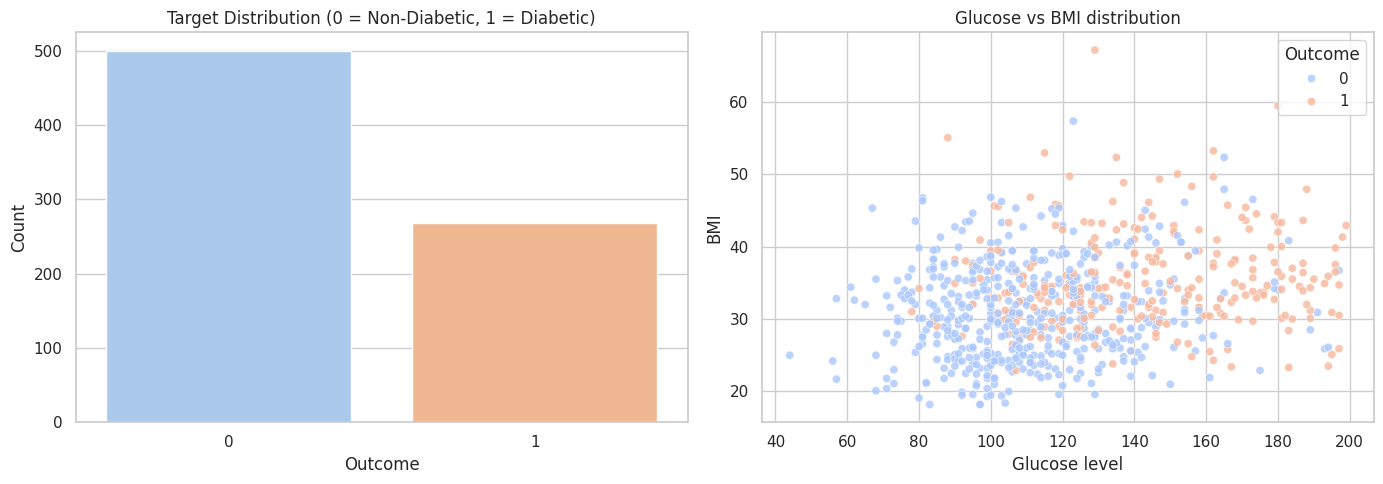

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Target class distribution
sns.countplot(data=df_raw, x="Outcome", ax=axes[0], palette="pastel")
axes[0].set_title("Target Distribution (0 = Non-Diabetic, 1 = Diabetic)")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Count")

#Glucose vs BMI grouped by outcome
sns.scatterplot(
    data=df_raw,
    x="Glucose",
    y="BMI",
    hue="Outcome",
    palette="coolwarm",
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Glucose vs BMI distribution")
axes[1].set_xlabel("Glucose level")
axes[1].set_ylabel("BMI")

plt.tight_layout()
plt.show()

In [8]:
df = df_raw.copy()

# Features where 0 indicates anu nrecorded measurement rather than a valid medical value
zero_invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[zero_invalid_cols] = df[zero_invalid_cols].replace(0, np.nan)

for col in zero_invalid_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

print("Total missing values after cleaning:", df.isnull().sum().sum())
df.describe().T[["mean", "std", "min", "50%", "max"]]

Total missing values after cleaning: 0


,mean,std,min,50%,max
Pregnancies,3.845052,3.369578,0.000,3.0000,17.00
Glucose,121.677083,30.464161,44.000,117.0000,199.00
BloodPressure,72.389323,12.106039,24.000,72.0000,122.00
SkinThickness,29.089844,8.890820,7.000,28.0000,99.00
Insulin,141.753906,89.100847,14.000,102.5000,846.00
BMI,32.434635,6.880498,18.200,32.0500,67.10
DiabetesPedigreeFunction,0.471876,0.331329,0.078,0.3725,2.42
Age,33.240885,11.760232,21.000,29.0000,81.00
Outcome,0.348958,0.476951,0.000,0.0000,1.00


In [11]:
# Separatedd features and target
X = df.drop(columns=["Outcome"])
y = df["Outcome"].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 614 samples
Testing set size: 154 samples


In [13]:
# Support vector classifier
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Decision tree classifier
dt_model = DecisionTreeClassifier(max_depth=4, criterion="gini", random_state=42)
dt_model.fit(X_train, y_train)

# predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_dt = dt_model.predict(X_test)

# testing accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Model Performance on Test Set")
print(f"(SVM) Accuracy : {acc_svm * 100:.2f}%")
print(f"Decision Tree Accuracy   : {acc_dt * 100:.2f}%")

Model Performance on Test Set
(SVM) Accuracy : 83.77%
Decision Tree Accuracy   : 83.77%


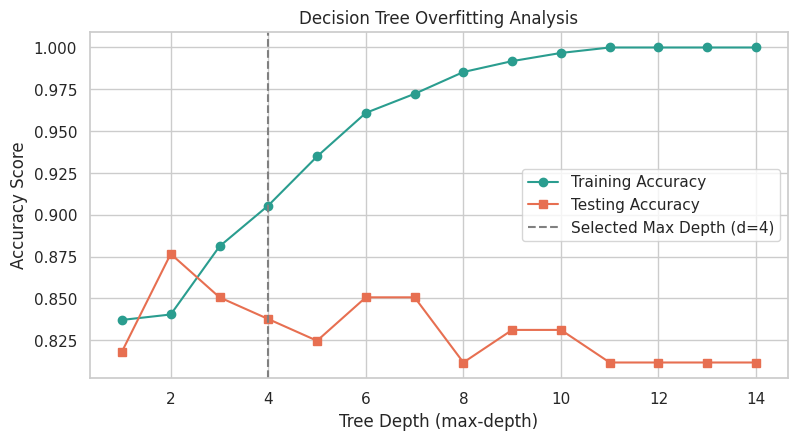

In [15]:
#Decision Tree
depths = range(1, 15)
train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 4.5))
plt.plot(depths, train_scores, marker="o", label="Training Accuracy", color="#2a9d8f")
plt.plot(depths, test_scores, marker="s", label="Testing Accuracy", color="#e76f51")
plt.axvline(x=4, color="gray", linestyle="--", label="Selected Max Depth (d=4)")
plt.title("Decision Tree Overfitting Analysis")
plt.xlabel("Tree Depth (max-depth)")
plt.ylabel("Accuracy Score")
plt.legend()
plt.show()

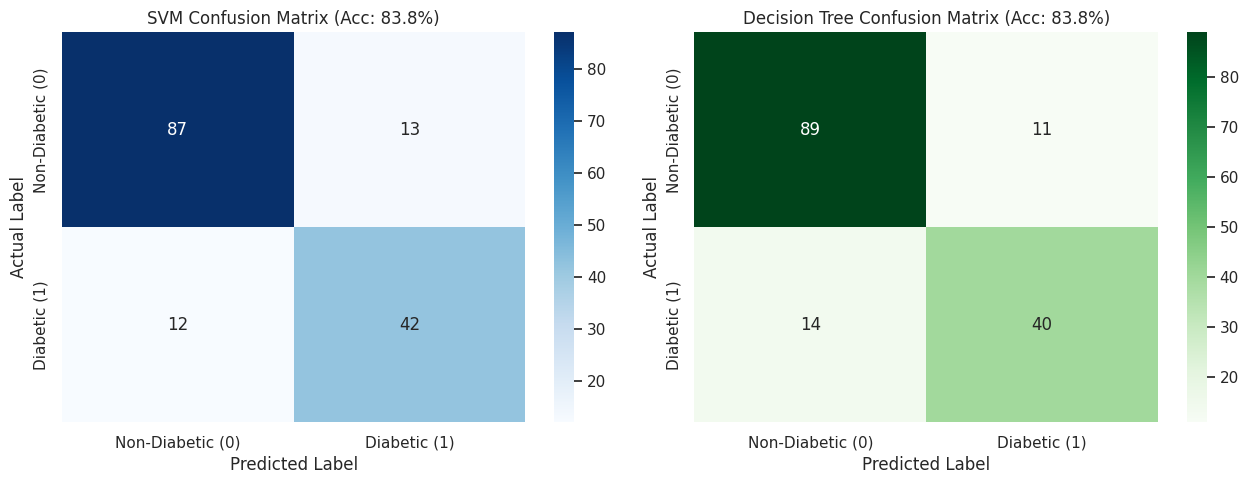


SVM Report
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.88      0.87      0.87       100
    Diabetic (1)       0.76      0.78      0.77        54

        accuracy                           0.84       154
       macro avg       0.82      0.82      0.82       154
    weighted avg       0.84      0.84      0.84       154

Decision Tree Reportt
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.86      0.89      0.88       100
    Diabetic (1)       0.78      0.74      0.76        54

        accuracy                           0.84       154
       macro avg       0.82      0.82      0.82       154
    weighted avg       0.84      0.84      0.84       154



In [16]:
class_labels = ["Non-Diabetic (0)", "Diabetic (1)"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title(f"SVM Confusion Matrix (Acc: {acc_svm * 100:.1f}%)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title(f"Decision Tree Confusion Matrix (Acc: {acc_dt * 100:.1f}%)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

print("\nSVM Report")
print(classification_report(y_test, y_pred_svm, target_names=class_labels))

print("Decision Tree Reportt")
print(classification_report(y_test, y_pred_dt, target_names=class_labels))

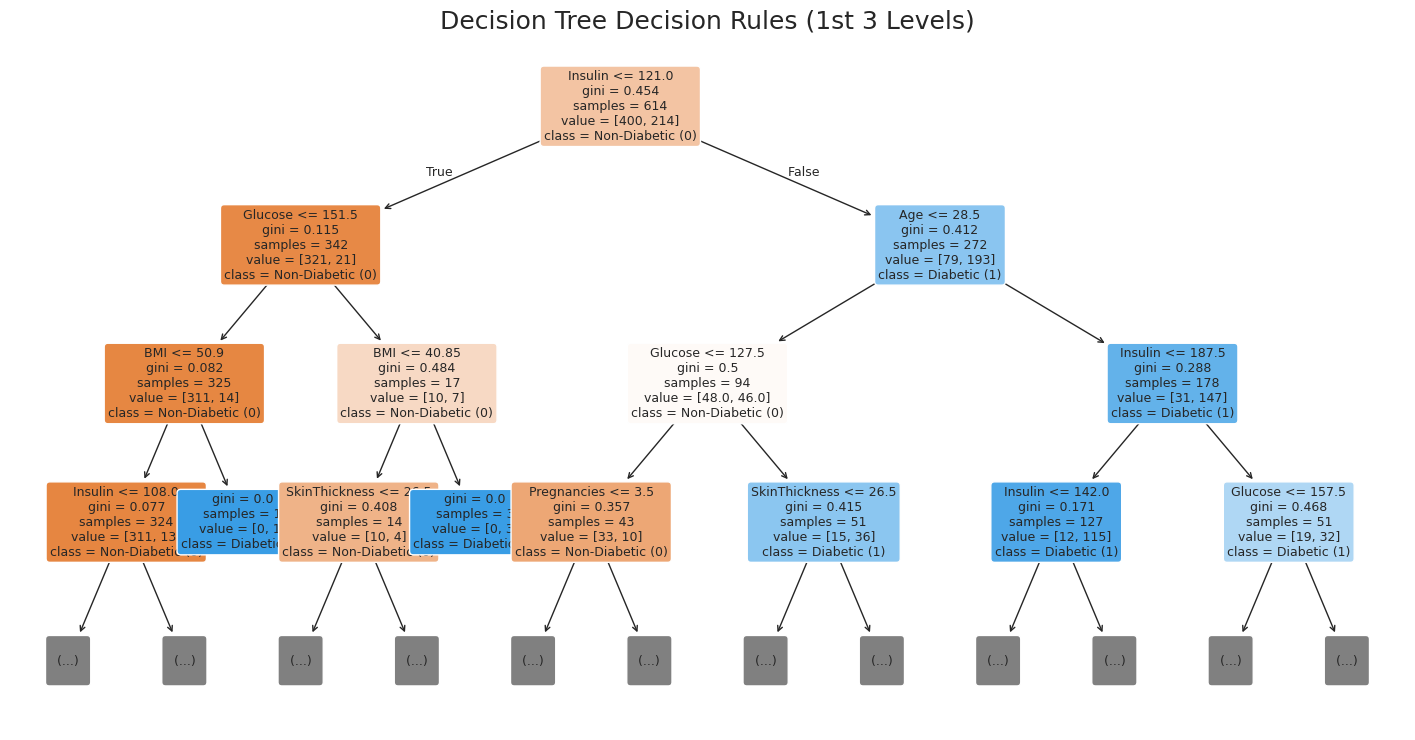

In [24]:
plt.figure(figsize=(18, 9))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=class_labels,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)
plt.title("Decision Tree Decision Rules (1st 3 Levels)", fontsize=18)
plt.show()

In [22]:
def predict_diabetes(patient_data):
    # Convert input to DataFrame matching training feature columns
    feature_order = [
        "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
        "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
    ]
    df_input = pd.DataFrame([patient_data])[feature_order]

    #Scale features for SVM ]
    input_scaled = scaler.transform(df_input)

    # Predict class outcomes (0 = Non-Diabetic, 1 = Diabetic)
    svm_prediction = svm_model.predict(input_scaled)[0]
    dt_prediction = dt_model.predict(df_input)[0]

    # Map labels
    labels = {0: "Low Risk / Non-Diabetic", 1: "High Risk / Diabetic"}


    print("        PATIENT DIABETES RISK REPORT         ")
    print(f"SVM Prediction           : {labels[svm_prediction]}")
    print(f"Decision Tree Prediction : {labels[dt_prediction]}")

In [23]:
# Sample Patient Data to check
new_patient = {
    "Pregnancies": 2,
    "Glucose": 145,
    "BloodPressure": 75,
    "SkinThickness": 32,
    "Insulin": 130,
    "BMI": 33.2,
    "DiabetesPedigreeFunction": 0.45,
    "Age": 42
}

predict_diabetes(new_patient)

        PATIENT DIABETES RISK REPORT         
SVM Prediction           : High Risk / Diabetic
Decision Tree Prediction : High Risk / Diabetic


### Overfitting vs. Accuracy Trade-Offs

**1. Pre-processing**
Zeros in Glucose, BMI, and Insulin aren't possible for living patients, so I treated them as missing and filled them in. I also scaled the features with StandardScaler so the SVM wasn't thrown off by large-valued columns.

**2. Model comparison**
The SVM (RBF kernel) generalized well on the test set. The decision tree was easier to interpret since you can see the exact cutoffs, like glucose level, behind each prediction.

**3. Overfitting**
An unrestricted decision tree hits nearly 100% training accuracy but does worse on test data because it memorizes noise. Setting max_depth=4 fixed this and gave a better balance between bias and variance.